Video 360° e Proiezioni Equirettangolari

## Obiettivi della lezione

In questo laboratorio impareremo a:

1. Caricare ed ispezionare un video a 360° codificato in proiezione **equirettangolare (ERP)**;
2. Estrarre frame rappresentativi ed osservare empiricamente le distorsioni tipiche del formato;
3. Convertire un frame ERP in proiezione **cubemap** con `py360convert`;
4. Estrarre **viewport** prospettiche arbitrarie (quello che vedrebbe un utente con un visore VR);

**Prerequisiti:** Lezione precedente (lettura video con `cv2.VideoCapture`, scrittura con `cv2.VideoWriter`). Non ripetiamo qui la sintassi di base già vista: la richiamiamo solo dove necessario.

**Strumenti:** Python, OpenCV, `py360convert`.

In [1]:
# Import delle librerie necessarie per l'intera lezione
import os
import time

import numpy as np
import cv2
import matplotlib.pyplot as plt

import py360convert  # pip install py360convert

print("OpenCV:", cv2.__version__)
print("py360convert:", py360convert.__version__)

OpenCV: 4.13.0
py360convert: 1.0.4


## 1. Caricamento e ispezione di un video equirettangolare

### Richiamo teorico: la proiezione equirettangolare (ERP)

Un video 360° cattura l'intera sfera visiva attorno alla camera. Per poterlo memorizzare e comprimere con i codec video standard (pensati per immagini rettangolari planari), la sfera viene "srotolata" su un piano tramite una **proiezione**. La più diffusa è la **proiezione equirettangolare (Equirectangular Projection, ERP)**:

- la **longitudine** (angolo orizzontale attorno alla sfera, da −180° a +180°) è mappata linearmente sulla coordinata **x** del frame;
- la **latitudine** (angolo verticale, da −90° al polo sud a +90° al polo nord) è mappata linearmente sulla coordinata **y**;
- ne consegue che l'aspect ratio standard di un frame ERP è **2:1** (360° di longitudine contro 180° di latitudine).

Questa mappatura è semplice da implementare ed è comoda perché produce un frame rettangolare "normale" per codec e contenitori esistenti. Il prezzo da pagare, come vedremo empiricamente, è una **distorsione di campionamento fortemente non uniforme**: un'area della sfera vicina al polo occupa, in ERP, la stessa larghezza orizzontale (in pixel) di un'area equivalente all'equatore, pur rappresentando una porzione di superficie sferica molto più piccola. Al polo stesso — un singolo punto geometrico — corrisponde un'intera riga di pixel.

![EPR](imgs/epr.png)
![EPR](imgs/epr2.png)

Il video a 360 gradi che verrà usato in questo laboratorio è possibile scaricarlo da qui

https://drive.google.com/file/d/1ggdL201jeRtQ7CDgMZbx6Qo6KxP0RTLx/view?usp=sharing

E' possibile scaricare altri video da qui 

https://www.pexels.com/it-IT/cerca/videos/360/?orientation=landscape

In [ ]:
ERP_VIDEO_PATH = "sample.mp4"
ERP_IMAGE_PATH = "frame.jpg"

In [9]:
# --- Caricamento e ispezione del video (riuso di quanto visto in Lezione 5) --
cap = cv2.VideoCapture(ERP_VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Impossibile aprire il video: {ERP_VIDEO_PATH}")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_video = cap.get(cv2.CAP_PROP_FPS)
n_total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Risoluzione: {width} x {height}")
print(f"Aspect ratio: {width / height:.3f}")   # verificare empiricamente se è 2.0
print(f"FPS: {fps_video}")
print(f"Numero di frame: {n_total_frames}")

# Verifica esplicita: e' effettivamente un aspect ratio 2:1?
# NON dare per scontato che ogni video "360" rispetti questa convenzione:
# alcuni file monoscopici la rispettano, altri (es. formati stereo
# top-bottom o side-by-side) hanno un aspect ratio diverso (es. 1:1).
is_erp_2to1 = abs((width / height) - 2.0) < 0.01
print(f"Rispetta la convenzione ERP 2:1? {is_erp_2to1}")

cap.release()

Risoluzione: 4320 x 2160
Aspect ratio: 2.000
FPS: 50.0
Numero di frame: 1187
Rispetta la convenzione ERP 2:1? True


### Nota

L'aspect ratio 2:1 non è una convenzione arbitraria: discende direttamente dalla geometria della proiezione equirettangolare.
La ragione geometrica
L'ERP mappa linearmente:

* la longitudine, che copre l'intero giro attorno alla sfera: 360°
* la latitudine, che copre solo la metà di un giro (dal polo sud al polo nord): 180°

Se la mappatura è lineare in entrambi gli assi (un grado di longitudine occupa lo stesso numero di pixel orizzontali di un grado di latitudine in verticale), il rapporto tra i due intervalli angolari — 360°/180° = 2 — si traduce direttamente nel rapporto tra larghezza e altezza del frame. 

Non tutti i file "360" sono ERP monoscopica pura. Formati stereoscopici (per visori VR) impilano due viste ERP (una per occhio) in **top-bottom** o **side-by-side**, cambiando l'aspect ratio complessivo (es. 1:1 invece di 2:1). Prima di applicare qualsiasi elaborazione basata sull'assunzione di ERP 2:1, è buona pratica **verificare programmaticamente** l'aspect ratio del file, come fatto sopra, invece di assumerlo a priori dal nome del file o dal contesto.

## 2. Estrazione di frame rappresentativi

Estraiamo alcuni frame a intervalli regolari, secondo lo stesso approccio di campionamento temporale già usato in Lezione 5, e li visualizziamo per osservare **empiricamente** — non genericamente — le distorsioni introdotte dalla proiezione ERP sul contenuto specifico di questo video.

Estratti 4 frame agli indici: [0, 395, 790, 1186]


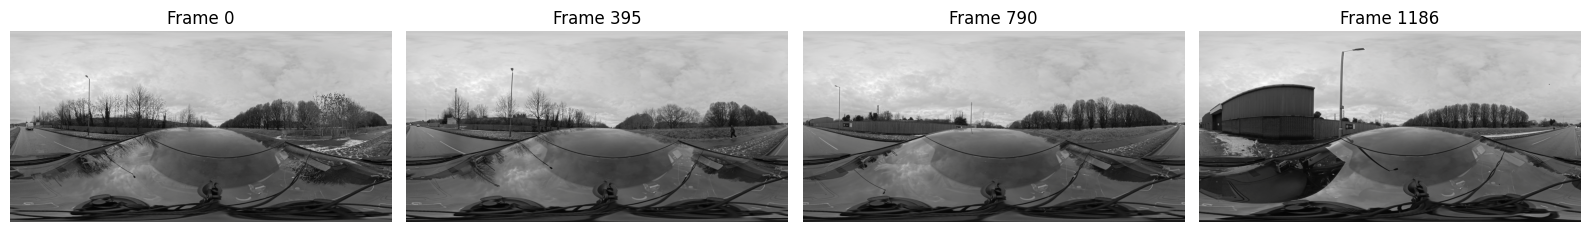

In [11]:
# Estrazione di frame a intervalli regolari (campionamento a passo fisso)
N_SAMPLES = 4
cap = cv2.VideoCapture(ERP_VIDEO_PATH)
n_total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

sample_indices = np.linspace(0, n_total_frames - 1, N_SAMPLES, dtype=int)
sampled_frames = []

for idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))  # posiziona il cursore sul frame idx
    ret, frame = cap.read()
    if not ret:
        print(f"Attenzione: lettura fallita al frame {idx}")
        continue
    sampled_frames.append((int(idx), cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

cap.release()
print(f"Estratti {len(sampled_frames)} frame agli indici: {[i for i, _ in sampled_frames]}")

fig, axes = plt.subplots(1, len(sampled_frames), figsize=(16, 4))
for ax, (idx, frame) in zip(axes, sampled_frames):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Osservazione empirica sulla distorsione polare

Guardando i frame estratti sopra, la calotta superiore e quella inferiore occupano **l'intera larghezza del frame** con un'altezza fissa, indipendentemente da quanto "piccola" sia in realtà l'area vicino al polo sulla sfera. Le bande equatoriali, invece, hanno tutte la stessa larghezza in pixel pur corrispondendo tutte a 90° di longitudine — cosa corretta solo all'equatore.

Su un video reale questo si traduce in oggetti vicino allo zenit/nadir (es. il soffitto di una stanza, il cielo, il pavimento) fortemente **stirati orizzontalmente**, un artefatto tipico e immediatamente riconoscibile dei contenuti ERP.

![EPR IMG](epr_img.jpg)

## 3. Dalla ERP al cubemap con `py360convert`

### Richiamo teorico: perché il cubemap

Come osservato sopra, l'ERP campiona la sfera in modo **fortemente non uniforme**: la densità di pixel per unità di superficie sferica cresce man mano che ci si avvicina ai poli. Questo non è solo un problema estetico: significa che stiamo "sprecando" bit per codificare informazione ridondante ai poli, mentre l'equatore (spesso la zona di maggiore interesse visivo) non riceve un trattamento privilegiato.

La proiezione **cubemap** affronta il problema diversamente: la sfera viene proiettata sulle **6 facce di un cubo** che la inscrive (front, right, back, left, up, down). Ogni faccia è una proiezione **prospettica** (non equirettangolare) di 90°×90° di campo visivo, con una distorsione molto più uniforme e limitata alla propria faccia, invece che concentrata ai poli come nell'ERP.

![](hdri2cubemap.png)

### Nota

Il cubemap non elimina la distorsione — nessuna proiezione di una sfera su un piano può farlo (è lo stesso problema della cartografia terrestre) — ma la **ridistribuisce**: cresce verso gli angoli di ciascuna faccia, invece che concentrarsi tutta ai due poli come nell'ERP. Questa proprietà è alla base di molte tecniche di **codifica e streaming adattivo** che vedremo nella discussione finale-

In [13]:
# Carichiamo il frame di test e lo convertiamo in RGB
# (OpenCV usa BGR internamente, py360convert e matplotlib si aspettano RGB)
erp_frame_bgr = cv2.imread(ERP_IMAGE_PATH)
erp_frame_rgb = cv2.cvtColor(erp_frame_bgr, cv2.COLOR_BGR2RGB)
print("Shape del frame ERP:", erp_frame_rgb.shape)

# Conversione ERP -> cubemap con py360convert.
# face_w: risoluzione (in pixel) di ciascuna faccia del cubo (quadrata)
# mode: metodo di interpolazione per il campionamento
# cube_format='dict': restituisce un dizionario {chiave: faccia}, comodo
#                     per accedere alle singole facce per nome
t0 = time.time()
cube_faces = py360convert.e2c(
    erp_frame_rgb,
    face_w=256,
    mode="bilinear",
    cube_format="dict",
)
elapsed = time.time() - t0
print(f"Conversione completata in {elapsed*1000:.1f} ms")
print("Facce prodotte:", list(cube_faces.keys()))  # F, R, B, L, U, D
for name, face in cube_faces.items():
    print(f"  faccia '{name}': shape={face.shape}, dtype={face.dtype}")

Shape del frame ERP: (2160, 4320, 3)
Conversione completata in 42.8 ms
Facce prodotte: ['F', 'R', 'B', 'L', 'U', 'D']
  faccia 'F': shape=(256, 256, 3), dtype=uint8
  faccia 'R': shape=(256, 256, 3), dtype=uint8
  faccia 'B': shape=(256, 256, 3), dtype=uint8
  faccia 'L': shape=(256, 256, 3), dtype=uint8
  faccia 'U': shape=(256, 256, 3), dtype=uint8
  faccia 'D': shape=(256, 256, 3), dtype=uint8


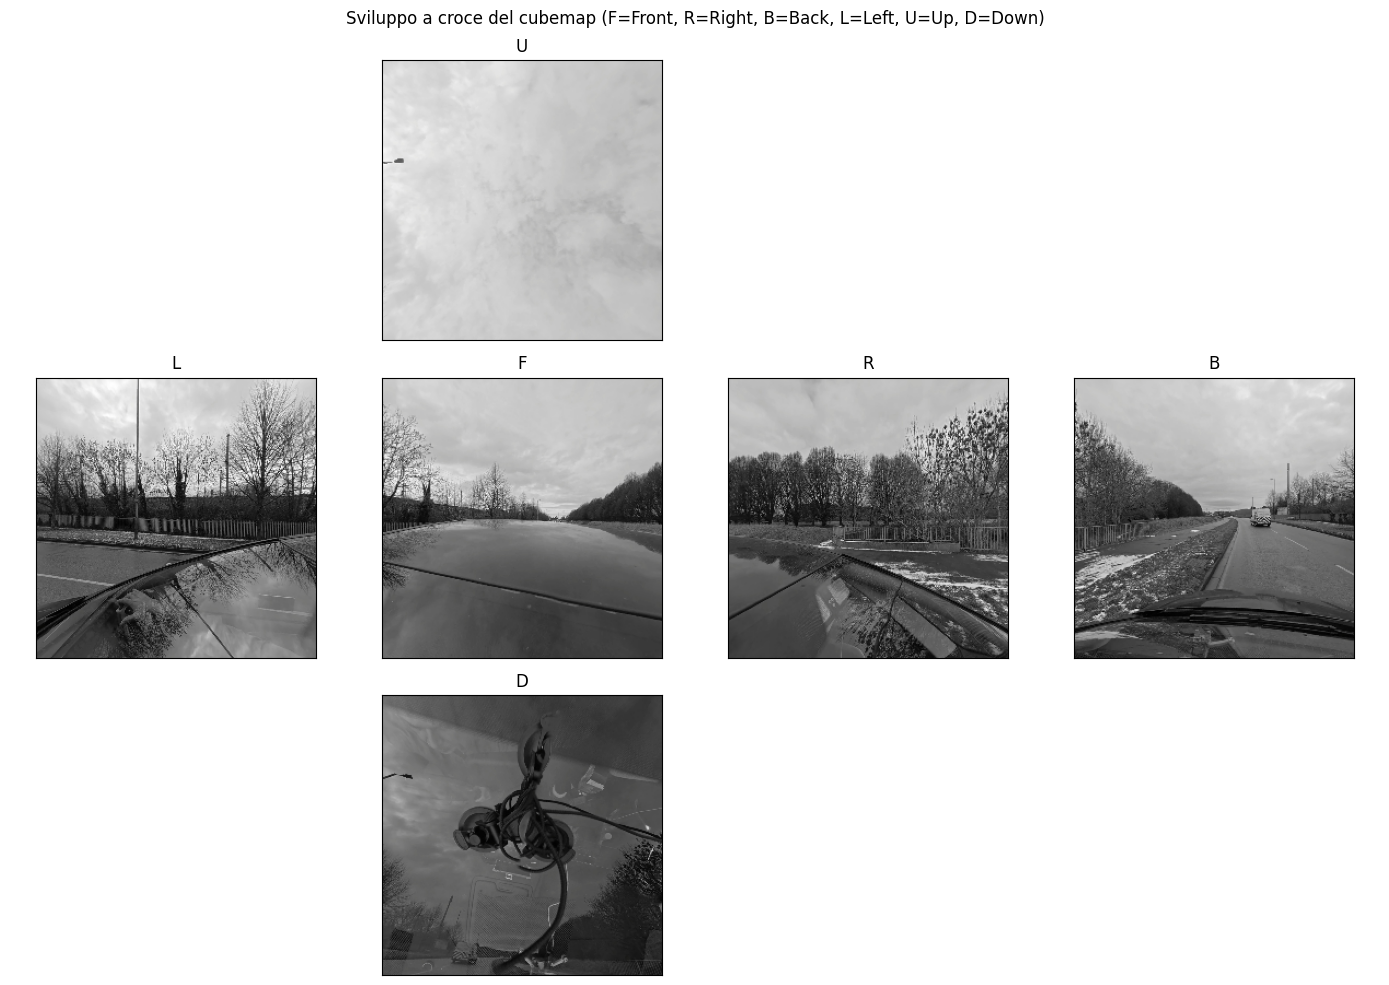

In [14]:
# Visualizziamo le 6 facce del cubemap in una griglia,
# disposte secondo lo sviluppo "a croce" tipico del formato cubemap
face_order = {
    "U": (0, 1), "L": (1, 0), "F": (1, 1),
    "R": (1, 2), "B": (1, 3), "D": (2, 1),
}
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax in axes.flat:
    ax.axis("off")
for name, (r, c) in face_order.items():
    axes[r, c].imshow(cube_faces[name])
    axes[r, c].set_title(name)
    axes[r, c].axis("on")
    axes[r, c].set_xticks([])
    axes[r, c].set_yticks([])
plt.suptitle("Sviluppo a croce del cubemap (F=Front, R=Right, B=Back, L=Left, U=Up, D=Down)")
plt.tight_layout()
plt.show()

### Osservazione empirica

Notiamo come, sulle facce **U** (up) e **D** (down), l'etichetta del polo appaia ora come una **piccola forma compatta al centro della faccia**, invece della linea orizzontale a piena larghezza vista nell'ERP: la stessa informazione (il polo) occupa uno spazio visivo molto più limitato e coerente con la sua reale estensione sferica. Questo è esattamente l'effetto di ridistribuzione della distorsione discusso sopra — verificalo confrontando questa figura con i frame della Sezione 2.

Il tempo di conversione misurato sopra (qualche decina di millisecondi per frame, sull'hardware di questo notebook) va tenuto a mente quando si progetta una pipeline che debba processare **un intero video** frame-per-frame piuttosto che un singolo frame: su una sequenza lunga, conviene valutare se il costo computazionale è compatibile con i tempi richiesti (elaborazione offline vs. tempo reale).

## 4. Estrazione di viewport arbitrarie

### Richiamo teorico: cos'è una viewport

Quando un utente guarda un video 360° con un visore VR (o trascina il video con il mouse in un player desktop), **non vede mai il frame ERP o il cubemap direttamente**: il player genera al volo una **proiezione prospettica** — la viewport — corrispondente alla direzione in cui l'utente sta guardando in quel momento, definita da tre parametri:

- **yaw**: rotazione orizzontale (sinistra/destra), corrisponde alla longitudine;
- **pitch**: rotazione verticale (su/giù), corrisponde alla latitudine;
- **roll**: rotazione attorno all'asse di vista (la direzione verso cui si sta guardando), inclina l'orizzonte senza cambiare il punto osservato.
- **FOV (field of view)**: ampiezza angolare del campo visivo simulato (tipicamente 90°–110° per un visore VR).

La viewport è quindi concettualmente **una singola faccia "orientabile" del cubemap**, non vincolata alle 6 direzioni fisse (front/right/back/left/up/down), ma calcolabile per qualunque combinazione di yaw e pitch.

![Rotations](rotations.jpg)

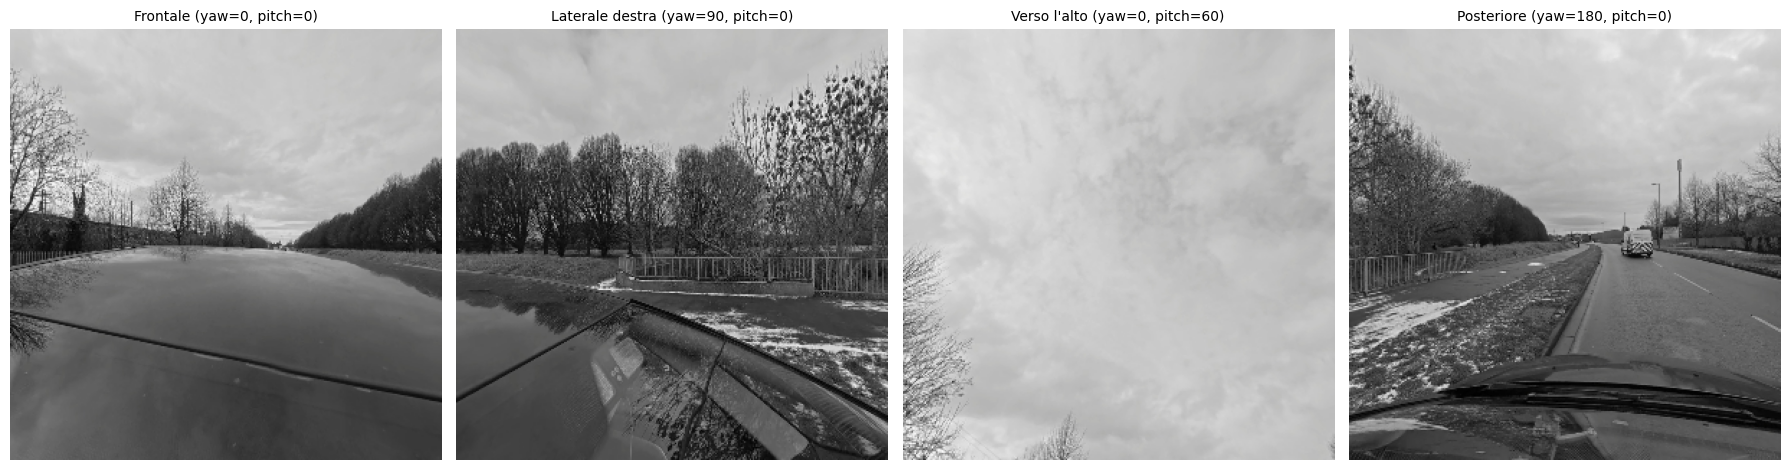

In [15]:
# py360convert.e2p: estrae una viewport prospettica dal frame ERP
#   fov_deg : ampiezza del campo visivo in gradi (puo' essere una tupla
#             (fov_orizzontale, fov_verticale) o un singolo valore)
#   u_deg   : yaw, rotazione orizzontale in gradi (0 = centro del frame ERP)
#   v_deg   : pitch, rotazione verticale in gradi (0 = equatore, 90 = polo nord)
#   out_hw  : dimensioni (altezza, larghezza) dell'immagine di output

viewports = {
    "Frontale (yaw=0, pitch=0)": (0, 0),
    "Laterale destra (yaw=90, pitch=0)": (90, 0),
    "Verso l'alto (yaw=0, pitch=60)": (0, 60),
    "Posteriore (yaw=180, pitch=0)": (180, 0),
}

fig, axes = plt.subplots(1, len(viewports), figsize=(18, 5))
for ax, (title, (yaw, pitch)) in zip(axes, viewports.items()):
    vp = py360convert.e2p(
        erp_frame_rgb,
        fov_deg=90,
        u_deg=yaw,
        v_deg=pitch,
        out_hw=(300, 300),
    )
    ax.imshow(vp)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Esercizio guidato

Osserva come, nella viewport frontale, le linee della griglia (dritte sulla sfera) appaiano **curve** nell'immagine prospettica: è la normale distorsione prospettica (la stessa di un obiettivo grandangolare), diversa e concettualmente distinta dalla distorsione di campionamento della proiezione ERP discussa in precedenza. Confronta inoltre la porzione di scena visibile nella viewport "verso l'alto" con la calotta polare vista nell'ERP: nota come una regione che nell'ERP appariva come una fascia orizzontale sottile occupi qui una porzione ben più ampia e centrata del campo visivo.

In [ ]:
# Confronto quantitativo: quanta area della sfera "pesa" la stessa
# porzione angolare a seconda della latitudine.
# Prendiamo una porzione di 30 gradi di longitudine a diverse latitudini
# e confrontiamo la sua larghezza in pixel nell'ERP originale.
for lat_test in [0, 30, 60, 80]:
    x0, y0 = lonlat_to_xy(-15, lat_test)
    x1, _ = lonlat_to_xy(15, lat_test)
    width_px = (x1 - x0) if x1 > x0 else (x1 - x0 + W)
    print(f"Latitudine {lat_test:>3}°: 30° di longitudine occupano {width_px} px in larghezza nell'ERP")

# Nota: la larghezza in pixel di una stessa fascia angolare di longitudine
# resta COSTANTE nell'ERP a ogni latitudine (è una proiezione lineare),
# mentre l'area sferica reale che quella fascia rappresenta si riduce
# proporzionalmente a cos(latitudine), tendendo a zero ai poli.
import math
for lat_test in [0, 30, 60, 80]:
    relative_area = math.cos(math.radians(lat_test))
    print(f"Latitudine {lat_test:>3}°: fattore di area relativa cos(lat) = {relative_area:.3f}")

Questo secondo blocco di stampe rende esplicito, con numeri reali, il meccanismo della distorsione: la larghezza in pixel di una fascia di longitudine è costante nell'ERP a ogni latitudine, mentre l'area sferica reale rappresentata da quella fascia decresce con `cos(latitudine)` — a 80° di latitudine, quella stessa fascia di pixel rappresenta meno di un quinto dell'area che rappresenterebbe all'equatore. Questo è precisamente il fattore di ponderazione alla base delle metriche di qualità come **WS-PSNR**, che vedremo nella discussione finale.

##  Riepilogo ed esercizio per casa

### Riepilogo

- La proiezione **equirettangolare (ERP)** mappa linearmente longitudine/latitudine su x/y, con aspect ratio 2:1, ma campiona la sfera in modo non uniforme (sovracampionamento ai poli).
- La proiezione **cubemap** ridistribuisce questa distorsione su 6 facce prospettiche, in modo più uniforme.
- Una **viewport** è una proiezione prospettica arbitraria (yaw, pitch, FOV), concettualmente una faccia "orientabile" del cubemap: è ciò che un utente vede effettivamente in un player 360°/VR.

### Esercizio per casa (facoltativo)

Utilizzando `py360convert.e2p`, genera una sequenza di viewport estratte dallo stesso frame ERP con **yaw crescente** (ad esempio da 0° a 360° a passi di 10°, mantenendo pitch=0 e FOV=90°), simulando il movimento della testa di un utente che si guarda attorno. Componi le viewport risultanti in una breve clip video con `cv2.VideoWriter` (riutilizzando la correzione del codec vista in Lezione 5).

**Domanda di riflessione da preparare per la prossima lezione teorica:** se dovessi progettare uno schema di codifica *viewport-adaptive* per lo streaming live di un evento 360° (es. un concerto), quali informazioni ti servirebbero in tempo reale sul comportamento degli utenti, e quali compromessi dovresti accettare rispetto a una codifica uniforme dell'intero frame ERP?